In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

In [2]:
df = pd.read_csv('../data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [3]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


## Defining a baseline model
- A baseline model is a trivial solution to our problem. It often uses heuristics, or simple statistics, to generate predictions.
- The baseline model is the simplest solution you can think of—it should not require any training, and the cost of implementation should be very low.

- Common naive baseline is historical mean.


# Plot data with train/test split 

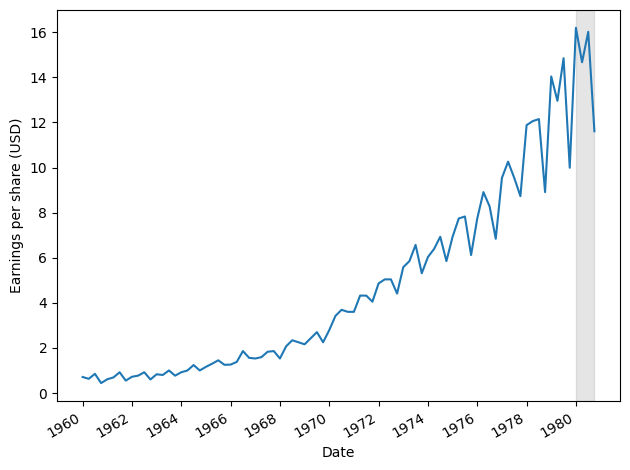

In [4]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F01_peixeiro.png', dpi=300)

# Split to train/test 

In [6]:
train = df[:-4]
test = df[-4:]

test.head()

,date,data
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


# Predict historical mean 

In [9]:
historical_mean = np.mean(train['data']) # Compute the arithmetic mean of the data column in the train set.
historical_mean

4.308499987499999

In [ ]:
test.loc[:, 'pred_mean'] = historical_mean # Set the historical mean as a forecast.

test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [10]:
# define the mean absolute percentage error (MAPE) function
# the MAPE returns the percentage of how much the forecast values deviate from the observed or actual values on average, 
# whether the prediction was higher or lower than the observed values
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [12]:
mape_hist_mean = mape(test['data'], test['pred_mean'])
mape_hist_mean

# Running the function gives a MAPE of 70.00%. 
# This means that our baseline deviates by 70% on average from the observed quarterly EPS of Johnson & Johnson in 1980

70.00752579965119

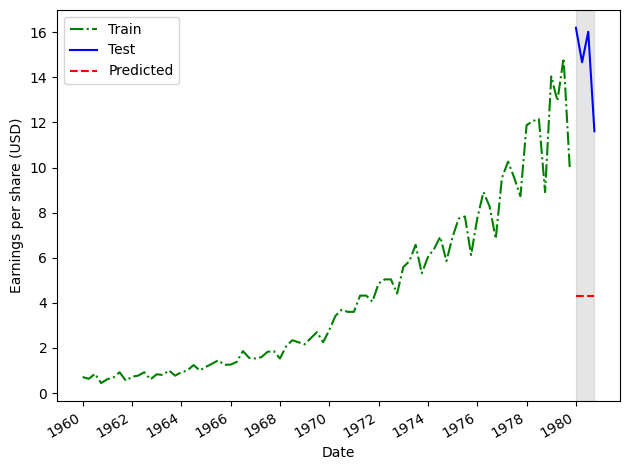

In [13]:
fig, ax = plt.subplots()

# 3 lines are drawn in the same plot: the original data in the train set, the test set data, and the predicted data (the historical mean)
ax.plot(train['date'], train['data'], 'g-.', label='Train') # Original data in the train set
ax.plot(test['date'], test['data'], 'b-', label='Test') # test set data
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted') # Preddicated data

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F06_peixeiro.png', dpi=300)

# Predict last year mean 

In [14]:
last_year_mean = np.mean(train['data'][-4:])
last_year_mean

12.96

In [15]:
test.loc[:, 'pred__last_yr_mean'] = last_year_mean

test

,date,data,pred_mean,pred__last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [22]:
mape_last_year_mean = mape(test['data'], test['pred__last_yr_mean'])
mape_last_year_mean

# The MAPE reduced to 15.59%
# We can learn from this baseline that future values likely depend on past values that are not too far back in history. This is a sign of autocorrelation

15.5963680725103

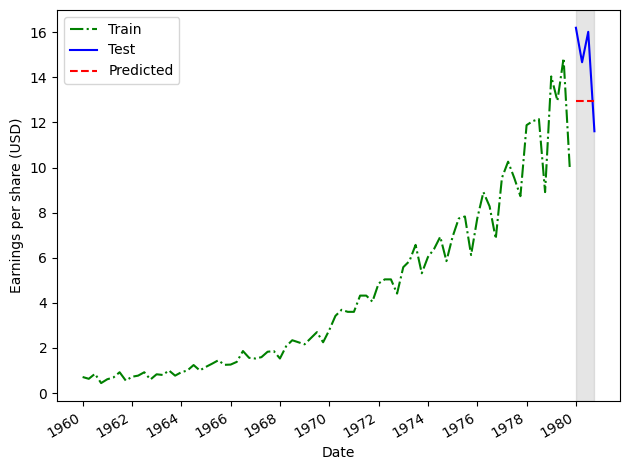

In [17]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred__last_yr_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F07_peixeiro.png', dpi=300)

# Predict last know value 

In [18]:
last = train['data'].iloc[-1]
last

9.99

In [19]:
test.loc[:, 'pred_last'] = last

test

,date,data,pred_mean,pred__last_yr_mean,pred_last
80,1980-01-01,16.20,4.3085,12.96,9.99
81,1980-04-01,14.67,4.3085,12.96,9.99
82,1980-07-02,16.02,4.3085,12.96,9.99
83,1980-10-01,11.61,4.3085,12.96,9.99


In [20]:
mape_last = mape(test['data'], test['pred_last'])
mape_last

30.457277908606535

- here MAPE increased to 30.45% the reason is 
- This can be explained by the fact that the EPS displays a cyclical behavior, where it is high during the first three quarters and then falls at the last quarter. 
- Using the last known value does not take the seasonality into account, so we need to use another naive forecasting technique to see if we can produce a better baseline.

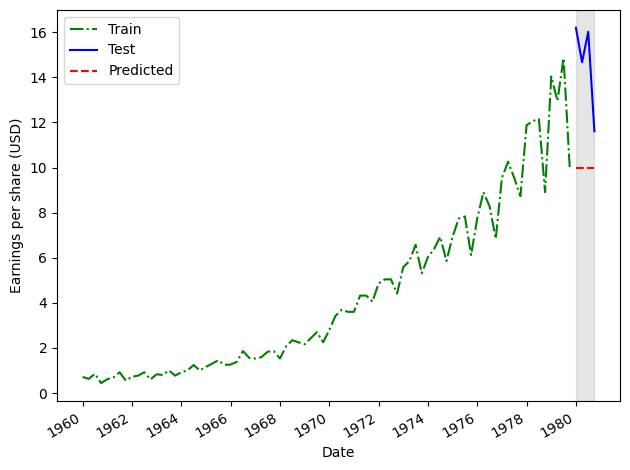

In [21]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F08_peixeiro.png', dpi=300)

# Naive seasonal forecast 

- In our case, a full cycle occurs in four quarters, 
    - so we will take the EPS from the first quarter of 1979 and predict that value for the first quarter of 1980. 
    - Then we’ll take the EPS from the second quarter of 1979 and predict that value for the second quarter of 1980.

In [23]:
# Our predictions are the last four values of our train set, which correspond to the quarters of 1979.
test.loc[:, 'pred_last_season'] = train['data'][-4:].values

test

,date,data,pred_mean,pred__last_yr_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [24]:
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])
mape_naive_seasonal

11.561658552433654

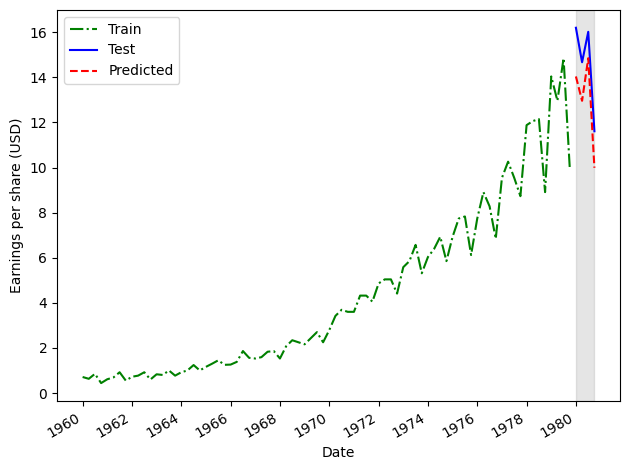

In [25]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F09_peixeiro.png', dpi=300)

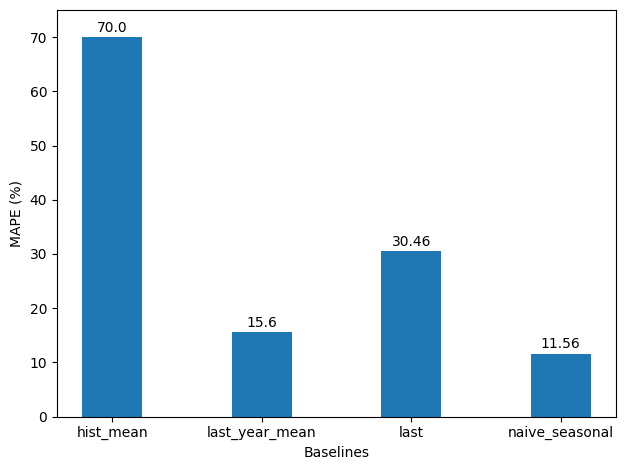

In [26]:
fig, ax = plt.subplots()

x = ['hist_mean', 'last_year_mean', 'last', 'naive_seasonal']
y = [70.00, 15.60, 30.46, 11.56]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Baselines')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha='center')

plt.tight_layout()

plt.savefig('figures/CH02_F10_peixeiro.png', dpi=300)